[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/pytorch-mastery/blob/main/02_core_deep_learning/04_regularization/regularization.ipynb)

# 10 . Regularization

## Concept — Regularization (revision notes)

**What it is**
- Any technique that reduces overfitting: it makes the model fit the training set slightly worse in exchange for generalising better to unseen data.
- Main tools: L2 / weight decay, L1, dropout, early stopping, data augmentation / noise injection, label smoothing.

**Why it matters**
- Big networks can memorise the training set, including its label noise. Training loss keeps falling while validation loss turns around and rises. The gap between the two is overfitting.
- Real datasets are small and noisy compared with model capacity, so some regularization is almost always needed.

**When to use**
- Whenever validation loss is much worse than training loss, or starts rising while training loss still falls.
- Start with weight decay + early stopping (cheap, nearly free), add dropout / augmentation if the gap persists.

**Math & intuition**
- L2: loss + (lambda/2) * sum(w^2). Gradient gains a term `lambda * w`, which shrinks every weight toward 0 each step ("decay"). Prefers many small weights.
- L1: loss + lambda * sum(|w|). Gradient is `lambda * sign(w)`, a constant pull that drives many weights to exactly ~0 (sparsity).
- Adam with L2 mixes the decay into the adaptive gradient scaling; AdamW applies the decay directly to the weights ("decoupled"), which is the correct and preferred form.
- Dropout zeroes each activation with probability p during training and rescales survivors by 1/(1-p) ("inverted dropout") so the expected activation is unchanged and nothing special is needed at test time. It acts like training an ensemble of thinned networks.
- Early stopping: keep the weights from the epoch with the best validation loss.
- Label smoothing: replace one-hot targets with (1-eps) on the true class and eps/K spread over the rest, discouraging over-confident logits.

### 1. A small noisy dataset that invites overfitting

**What this cell does (plain language):** we build a binary classification task with 20 features where only the first 3 matter, flip 10% of training labels as noise, and keep just 100 training points but 1000 clean validation points. A large network will have no trouble memorising those 100 points including the flipped labels.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.set_num_threads(1)     # tiny models: threading overhead costs more than it saves
torch.manual_seed(0)

D, N_TRAIN, N_VAL = 20, 100, 1000
w_true = torch.zeros(D); w_true[:3] = torch.tensor([2.0, -1.5, 1.0])   # only 3 informative features

def make_data(n, flip=0.0):
    X = torch.randn(n, D)
    y = ((X @ w_true) > 0).long()
    if flip > 0:                                          # label noise: flip a random subset
        mask = torch.rand(n) < flip
        y = torch.where(mask, 1 - y, y)
    return X, y

Xtr, ytr = make_data(N_TRAIN, flip=0.10)
Xva, yva = make_data(N_VAL, flip=0.0)
print("train", tuple(Xtr.shape), "val", tuple(Xva.shape))
print("best achievable val accuracy is 1.0 (clean val labels, true rule is linear in 3 features)")

train (100, 20) val (1000, 20)
best achievable val accuracy is 1.0 (clean val labels, true rule is linear in 3 features)


### 2. Helpers and the overfitting baseline

**What this cell does (plain language):** we define a model factory (a deliberately large MLP, 20-256-256-2) plus a `fit` function that trains full-batch and records train/validation loss every epoch. We train without any regularization and print the curves: training loss heads to ~0 while validation loss gets worse.

In [2]:
def make_model(p_drop=0.0, hidden=256):
    return nn.Sequential(
        nn.Linear(D, hidden), nn.ReLU(), nn.Dropout(p_drop),
        nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p_drop),
        nn.Linear(hidden, 2))

@torch.no_grad()
def evaluate(model, X, y):
    model.eval()                                         # disables dropout
    out = model(X)
    return F.cross_entropy(out, y).item(), (out.argmax(1) == y).float().mean().item()

def fit(model, opt, epochs=300, X=Xtr, y=ytr, loss_fn=F.cross_entropy, penalty=None, x_noise=0.0, patience=None):
    hist = {"train": [], "val": [], "val_acc": []}
    best = (float("inf"), None, -1); bad = 0
    for ep in range(epochs):
        model.train()
        xin = X + x_noise * torch.randn_like(X) if x_noise > 0 else X   # fresh noise every epoch
        opt.zero_grad()
        loss = loss_fn(model(xin), y)
        if penalty is not None:
            loss = loss + penalty(model)
        loss.backward(); opt.step()
        tl, _ = evaluate(model, X, y); vl, va = evaluate(model, Xva, yva)
        hist["train"].append(tl); hist["val"].append(vl); hist["val_acc"].append(va)
        if patience is not None:                         # early stopping bookkeeping
            if vl < best[0]:
                best = (vl, {k: v.clone() for k, v in model.state_dict().items()}, ep); bad = 0
            else:
                bad += 1
                if bad >= patience: break
    if patience is not None:
        model.load_state_dict(best[1]); hist["best_epoch"] = best[2]
    return hist

torch.manual_seed(0)
base = make_model()
h_base = fit(base, torch.optim.Adam(base.parameters(), lr=1e-3))
for ep in (0, 25, 50, 100, 299):
    print(f"epoch {ep:3d} | train loss {h_base['train'][ep]:.4f} | val loss {h_base['val'][ep]:.4f} | val acc {h_base['val_acc'][ep]:.3f}")
print("min val loss %.4f at epoch %d" % (min(h_base['val']), int(np.argmin(h_base['val']))))

epoch   0 | train loss 0.6504 | val loss 0.6659 | val acc 0.681
epoch  25 | train loss 0.0481 | val loss 0.4336 | val acc 0.817
epoch  50 | train loss 0.0017 | val loss 0.6430 | val acc 0.808
epoch 100 | train loss 0.0004 | val loss 0.7479 | val acc 0.804
epoch 299 | train loss 0.0001 | val loss 0.8636 | val acc 0.802
min val loss 0.3881 at epoch 17


### 3. Plotting the overfitting gap

**What this cell does (plain language):** we plot the baseline's train and validation loss. The point where the curves separate (validation turning upward while training keeps falling) is the signature of overfitting, and it is what every later technique tries to delay or shrink.

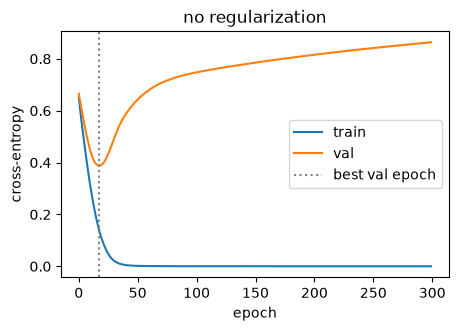

In [3]:
plt.figure(figsize=(5, 3.2))
plt.plot(h_base["train"], label="train"); plt.plot(h_base["val"], label="val")
plt.axvline(int(np.argmin(h_base["val"])), color="gray", ls=":", label="best val epoch")
plt.xlabel("epoch"); plt.ylabel("cross-entropy"); plt.title("no regularization"); plt.legend(); plt.show()

### 4. L2 regularization = weight decay (and why they match for SGD)

**What this cell does (plain language):** we show that, for plain SGD, adding an explicit `(lambda/2)*sum(w^2)` penalty to the loss gives exactly the same parameter update as the optimizer's `weight_decay=lambda` argument. We run one step each from identical weights and compare the results.

In [4]:
torch.manual_seed(1)
lam, lr = 0.1, 0.05
xb, yb = Xtr[:32], ytr[:32]

m1 = make_model(); m2 = make_model(); m2.load_state_dict(m1.state_dict())

# (a) explicit penalty added to the loss
opt1 = torch.optim.SGD(m1.parameters(), lr=lr)
penalty = 0.5 * lam * sum((p ** 2).sum() for p in m1.parameters())
(F.cross_entropy(m1(xb), yb) + penalty).backward(); opt1.step()

# (b) optimizer-level weight decay
opt2 = torch.optim.SGD(m2.parameters(), lr=lr, weight_decay=lam)
F.cross_entropy(m2(xb), yb).backward(); opt2.step()

same = all(torch.allclose(a, b, atol=1e-6) for a, b in zip(m1.parameters(), m2.parameters()))
print("explicit L2 penalty == SGD weight_decay after one step:", same)

explicit L2 penalty == SGD weight_decay after one step: True


### 5. Adam + L2 vs AdamW (decoupled decay)

**What this cell does (plain language):** we give one parameter a gradient of exactly zero and look at how each optimizer shrinks it. With Adam, weight decay is added to the gradient and then rescaled by Adam's normalisation, so the shrink step ends up about `lr` no matter how large the weight is. AdamW shrinks the weight by `lr * wd * w`, proportional to its size, which is the intended behaviour.

In [5]:
def one_step_shrink(opt_cls, w0, **kw):
    w = torch.nn.Parameter(torch.tensor([w0]))
    opt = opt_cls([w], lr=0.1, **kw)
    w.grad = torch.zeros_like(w)                          # no data gradient, ONLY the decay acts
    opt.step()
    return w.item()

for w0 in (0.1, 1.0, 10.0):
    a = one_step_shrink(torch.optim.Adam, w0, weight_decay=0.1)
    aw = one_step_shrink(torch.optim.AdamW, w0, weight_decay=0.1)
    print(f"w0={w0:5.1f} | Adam+wd shrinks by {w0 - a:.4f} | AdamW shrinks by {w0 - aw:.4f}  (lr*wd*w = {0.1*0.1*w0:.4f})")

w0=  0.1 | Adam+wd shrinks by 0.1000 | AdamW shrinks by 0.0010  (lr*wd*w = 0.0010)
w0=  1.0 | Adam+wd shrinks by 0.1000 | AdamW shrinks by 0.0100  (lr*wd*w = 0.0100)
w0= 10.0 | Adam+wd shrinks by 0.1000 | AdamW shrinks by 0.1000  (lr*wd*w = 0.1000)


### 6. Weight decay in practice (and which parameters to exclude)

**What this cell does (plain language):** we train with AdamW at a few weight-decay strengths and compare validation results. We also show the common pattern of two parameter groups: decay for weights (matrices) but not for biases, since shrinking biases doesn't regularise anything useful.

In [6]:
def adamw_groups(model, wd):
    decay = [p for n, p in model.named_parameters() if p.ndim > 1]      # weight matrices
    no_decay = [p for n, p in model.named_parameters() if p.ndim <= 1]  # biases (and norm params)
    return [{"params": decay, "weight_decay": wd}, {"params": no_decay, "weight_decay": 0.0}]

results = {}
for wd in (0.0, 0.1, 1.0, 3.0):
    torch.manual_seed(0)
    m = make_model()
    h = fit(m, torch.optim.AdamW(adamw_groups(m, wd), lr=1e-3))
    results[f"AdamW wd={wd}"] = (h["val"][-1], h["val_acc"][-1])
    print(f"wd={wd:<4} final train loss {h['train'][-1]:.4f} | final val loss {h['val'][-1]:.4f} | val acc {h['val_acc'][-1]:.3f}")

wd=0.0  final train loss 0.0001 | final val loss 0.8636 | val acc 0.802


wd=0.1  final train loss 0.0001 | final val loss 0.8344 | val acc 0.802


wd=1.0  final train loss 0.0004 | final val loss 0.7076 | val acc 0.801


wd=3.0  final train loss 0.0010 | final val loss 0.6217 | val acc 0.802


### 7. L1 regularization and sparsity

**What this cell does (plain language):** we fit a plain linear classifier (20 inputs, one logit pair) with an L1 penalty versus an L2 penalty and count weights that are essentially zero. L1's constant-magnitude pull drives uninformative weights to ~0; L2 only makes them small.

In [7]:
def count_small(model, tol=1e-2):
    w = model.weight.detach().abs().flatten()
    return int((w < tol).sum()), w.numel()

Xl, yl = make_data(500)
for name, pen in [("none", lambda m: 0.0),
                  ("L2 (0.05)", lambda m: 0.05 * (m.weight ** 2).sum()),
                  ("L1 (0.05)", lambda m: 0.05 * m.weight.abs().sum())]:
    torch.manual_seed(0)
    lin = nn.Linear(D, 2)
    opt = torch.optim.SGD(lin.parameters(), lr=0.05)
    for _ in range(2000):
        opt.zero_grad()
        (F.cross_entropy(lin(Xl), yl) + pen(lin)).backward(); opt.step()
    small, total = count_small(lin)
    print(f"{name:10s} weights with |w|<0.01: {small:2d}/{total} | largest |w|: {lin.weight.abs().max():.3f}")

none       weights with |w|<0.01:  0/40 | largest |w|: 2.580


L2 (0.05)  weights with |w|<0.01: 14/40 | largest |w|: 0.719


L1 (0.05)  weights with |w|<0.01: 34/40 | largest |w|: 0.893


### 8. Dropout mechanics: inverted scaling and train/eval modes

**What this cell does (plain language):** we apply `nn.Dropout(0.5)` to a vector of ones to see the zeroing and the 1/(1-p) = 2x rescaling of survivors, check the average stays near 1, and confirm that in `eval()` mode dropout is a no-op. That train/eval difference is why forgetting `model.eval()` silently hurts evaluation.

In [8]:
torch.manual_seed(0)
drop = nn.Dropout(p=0.5)
x = torch.ones(10)
drop.train(); print("train mode:", drop(x))
print("mean over many draws (should be ~1):", torch.stack([drop(torch.ones(1000)).mean() for _ in range(50)]).mean().item())
drop.eval();  print("eval  mode:", drop(x))

# Same model, same input: two training-mode passes differ (random masks); eval passes are identical.
m = make_model(p_drop=0.5)
xb = Xtr[:4]
m.train(); print("train-mode outputs identical across calls:", torch.equal(m(xb), m(xb)))
m.eval();  print("eval-mode  outputs identical across calls:", torch.equal(m(xb), m(xb)))

train mode: tensor([0., 0., 2., 0., 0., 0., 2., 2., 0., 2.])
mean over many draws (should be ~1): 0.9945198893547058
eval  mode: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
train-mode outputs identical across calls: False
eval-mode  outputs identical across calls: True


### 9. Dropout in training, and early stopping

**What this cell does (plain language):** we train the big MLP with dropout p=0.3, and separately without dropout but with early stopping (patience 30, restoring the best-validation weights). We print the final validation numbers and the epoch early stopping chose. Don't assume dropout wins on this tiny problem; compare the actual numbers.

In [9]:
torch.manual_seed(0)
m = make_model(p_drop=0.3)
h_drop = fit(m, torch.optim.Adam(m.parameters(), lr=1e-3))
print(f"dropout 0.3     : final train loss {h_drop['train'][-1]:.4f} | val loss {h_drop['val'][-1]:.4f} | val acc {h_drop['val_acc'][-1]:.3f}")

torch.manual_seed(0)
m = make_model()
h_es = fit(m, torch.optim.Adam(m.parameters(), lr=1e-3), epochs=300, patience=30)
vl, va = evaluate(m, Xva, yva)                            # weights restored to the best epoch
print(f"early stopping  : stopped after {len(h_es['val'])} epochs, best epoch {h_es['best_epoch']} | val loss {vl:.4f} | val acc {va:.3f}")

dropout 0.3     : final train loss 0.0000 | val loss 0.9178 | val acc 0.805


early stopping  : stopped after 48 epochs, best epoch 17 | val loss 0.3881 | val acc 0.823


### 10. Noise injection (augmentation) and label smoothing

**What this cell does (plain language):** we add fresh Gaussian noise to the inputs each epoch (a simple form of data augmentation: the model never sees exactly the same point twice) and, separately, use `label_smoothing=0.1` in the loss. For label smoothing we also look at the model's average confidence, which smoothing is designed to lower.

In [10]:
torch.manual_seed(0)
m = make_model()
h_noise = fit(m, torch.optim.Adam(m.parameters(), lr=1e-3), x_noise=0.2)
print(f"input noise 0.2 : final train loss {h_noise['train'][-1]:.4f} | val loss {h_noise['val'][-1]:.4f} | val acc {h_noise['val_acc'][-1]:.3f}")

def smooth_loss(logits, y): return F.cross_entropy(logits, y, label_smoothing=0.1)
torch.manual_seed(0)
m_ls = make_model()
h_ls = fit(m_ls, torch.optim.Adam(m_ls.parameters(), lr=1e-3), loss_fn=smooth_loss)
print(f"label smoothing : val acc {h_ls['val_acc'][-1]:.3f}")

with torch.no_grad():
    base.eval(); m_ls.eval()
    conf_base = F.softmax(base(Xva), 1).max(1).values.mean().item()
    conf_ls = F.softmax(m_ls(Xva), 1).max(1).values.mean().item()
print(f"mean max-probability on val | no smoothing: {conf_base:.3f} | smoothing: {conf_ls:.3f}")

input noise 0.2 : final train loss 0.0000 | val loss 0.8981 | val acc 0.793


label smoothing : val acc 0.771
mean max-probability on val | no smoothing: 0.949 | smoothing: 0.806


### 11. Putting it together: comparison table

**What this cell does (plain language):** we train the same model with each technique (and a combination: AdamW + dropout + early stopping) from identical seeds and print one table of best-reached validation loss and final validation accuracy. This is how you'd pick a regularizer in practice: measure on held-out data, not by guessing. One caveat: early stopping picks its epoch using the validation set, so its validation score is slightly optimistic; a real project would report on a separate test set.

In [11]:
import pandas as pd

def run(name, p_drop=0.0, wd=0.0, x_noise=0.0, smoothing=0.0, patience=None):
    torch.manual_seed(0)
    m = make_model(p_drop)
    opt = torch.optim.AdamW(adamw_groups(m, wd), lr=1e-3) if wd > 0 else torch.optim.Adam(m.parameters(), lr=1e-3)
    lf = (lambda lo, y: F.cross_entropy(lo, y, label_smoothing=smoothing))
    h = fit(m, opt, loss_fn=lf, x_noise=x_noise, patience=patience)
    vl, va = evaluate(m, Xva, yva)
    return {"method": name, "train loss (last)": round(h["train"][-1], 4), "val loss": round(vl, 4), "val acc": round(va, 3)}

rows = [run("baseline"),
        run("AdamW wd=1.0", wd=1.0),
        run("dropout 0.3", p_drop=0.3),
        run("input noise 0.2", x_noise=0.2),
        run("label smoothing 0.1", smoothing=0.1),
        run("early stopping", patience=30),
        run("combo: wd+dropout+ES", p_drop=0.3, wd=1.0, patience=30)]
print(pd.DataFrame(rows).to_string(index=False))

              method  train loss (last)  val loss  val acc
            baseline             0.0001    0.8636    0.802
        AdamW wd=1.0             0.0004    0.7076    0.801
         dropout 0.3             0.0000    0.9178    0.805
     input noise 0.2             0.0000    0.8981    0.793
 label smoothing 0.1             0.0513    0.4716    0.771
      early stopping             0.0022    0.3881    0.823
combo: wd+dropout+ES             0.0115    0.3804    0.819


## Common bugs

- **Forgetting `model.eval()` when validating** -> dropout stays on, validation numbers are noisy and pessimistic. Fix: `model.eval()` + `torch.no_grad()`, then `model.train()` again.
- **Using `Adam(weight_decay=...)` and expecting classic decay** -> L2 gets mixed into Adam's adaptive scaling (shown above). Fix: use `AdamW`.
- **Applying weight decay to biases and LayerNorm/BatchNorm parameters** -> unnecessary shrinkage that can hurt. Fix: parameter groups with `weight_decay=0` for 1-D params.
- **Weight decay set far too high** -> underfitting: both train and validation loss stay high. Fix: sweep values on a log scale (1e-4 ... 1e-1 for AdamW typically, bigger for tiny toy problems).
- **Early stopping on the training loss** (or on the test set) -> it never stops / you leak test data. Fix: monitor a separate validation set and restore the best weights.
- **Choosing hyperparameters on the test set** -> optimistic final numbers. Fix: tune on validation, touch test once at the end.
- **Dropout on tiny layers or right before the output logits** -> destroys signal. Fix: use it on wide hidden layers, with moderate p (0.1-0.5).
- **Combining BatchNorm with heavy dropout** -> the two interact (variance shift between train and eval). Fix: prefer one, or lower p.
- **Judging overfitting from a single seed on small data** -> differences of a point or two are noise. Fix: repeat across seeds before concluding.

## Exercises

**Exercise 1 - Measure the generalisation gap.**
Using the baseline history `h_base`, compute the gap `val loss - train loss` at epochs 10, 100 and 299, and say when it grows.

In [12]:
# Your attempt for Exercise 1 here

**Solution 1**

In [13]:
# Solution 1
for ep in (10, 100, 299):
    print(ep, round(h_base["val"][ep] - h_base["train"][ep], 4))

10 0.1389
100 0.7475
299 0.8635


**Exercise 2 - Manual L2 with AdamW vs Adam.**
Train two models for 100 epochs, one with `Adam(weight_decay=1e-2)` and one with `AdamW(weight_decay=1e-2)`, and print the total weight norm `sqrt(sum(w^2))` of each.

In [14]:
# Your attempt for Exercise 2 here

**Solution 2**

In [15]:
# Solution 2
def wnorm(m): return sum((p ** 2).sum() for p in m.parameters() if p.ndim > 1).sqrt().item()
for name, cls in [("Adam", torch.optim.Adam), ("AdamW", torch.optim.AdamW)]:
    torch.manual_seed(0); m = make_model()
    fit(m, cls(m.parameters(), lr=1e-3, weight_decay=1e-2), epochs=100)
    print(name, round(wnorm(m), 3))
# Adam+L2 ends with a different (here smaller) norm: the L2 gradient is rescaled by Adam's normalisation,
# so it is not the same as true decoupled decay. Exact values are specific to this run.

Adam 6.297


AdamW 14.932


**Exercise 3 - Dropout rate sweep.**
Train with dropout p in {0.0, 0.1, 0.3, 0.5, 0.7} and print the final validation accuracy for each.

In [16]:
# Your attempt for Exercise 3 here

**Solution 3**

In [17]:
# Solution 3
for p in (0.0, 0.1, 0.3, 0.5, 0.7):
    torch.manual_seed(0); m = make_model(p)
    h = fit(m, torch.optim.Adam(m.parameters(), lr=1e-3), epochs=200)
    print(p, round(h["val_acc"][-1], 3))

0.0 0.804


0.1 0.808


0.3 0.807


0.5 0.81


0.7 0.816


**Exercise 4 - Implement dropout by hand.**
Write `my_dropout(x, p, training)` using a Bernoulli mask and 1/(1-p) rescaling. Verify the mean is preserved and that `training=False` returns x unchanged.

In [18]:
# Your attempt for Exercise 4 here

**Solution 4**

In [19]:
# Solution 4
def my_dropout(x, p, training):
    if not training or p == 0: return x
    mask = (torch.rand_like(x) > p).float()
    return x * mask / (1 - p)
torch.manual_seed(0)
x = torch.ones(100000)
print(my_dropout(x, 0.3, True).mean().item(), torch.equal(my_dropout(x, 0.3, False), x))

1.0022001266479492 True


**Exercise 5 - Early stopping with a smaller dataset.**
Reduce training data to 40 samples, train with early stopping (patience 20) and print the stopping epoch. Does it stop earlier than with 100 samples? Explain in a comment.

In [20]:
# Your attempt for Exercise 5 here

**Solution 5**

In [21]:
# Solution 5
X40, y40 = Xtr[:40], ytr[:40]
for name, (X_, y_) in {"100 samples": (Xtr, ytr), "40 samples": (X40, y40)}.items():
    torch.manual_seed(0); m = make_model()
    h = fit(m, torch.optim.Adam(m.parameters(), lr=1e-3), X=X_, y=y_, patience=20)
    print(name, "best epoch", h["best_epoch"], "stopped after", len(h["val"]))
# Fewer samples are memorised sooner; the exact epochs depend on the noise in this particular draw.

100 samples best epoch 17 stopped after 38


40 samples best epoch 18 stopped after 39


**Exercise 6 - L1 + L2 (elastic net).**
Fit the linear classifier with both penalties (0.02 L1 + 0.02 L2) and report how many of 40 weights have |w|<0.01.

In [22]:
# Your attempt for Exercise 6 here

**Solution 6**

In [23]:
# Solution 6
torch.manual_seed(0); lin = nn.Linear(D, 2); opt = torch.optim.SGD(lin.parameters(), lr=0.05)
for _ in range(2000):
    opt.zero_grad()
    pen = 0.02 * lin.weight.abs().sum() + 0.02 * (lin.weight ** 2).sum()
    (F.cross_entropy(lin(Xl), yl) + pen).backward(); opt.step()
print(count_small(lin))

(34, 40)
